In [1]:
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

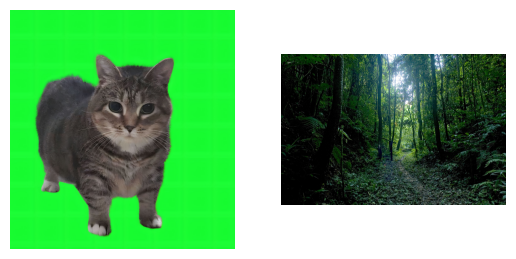

In [363]:
cat_img = plt.imread("src/images.jpg")[:1750, 250:]
bg_img = plt.imread("src/forest.jpg")
fig, ax = plt.subplots(nrows=1, ncols=2)
# bg_img = bg_img[:cat_img.shape[0], :cat_img.shape[1], :]
ax[0].imshow(cat_img)
ax[0].axis("off")
ax[1].imshow(bg_img)
ax[1].axis("off")

In [299]:
def img_to_gray(img):
    # return 0.36 * img[:, :, 0] + 0.53 * img[:, :, 1] + 0.11 * img[:, :, 2]
    return img[:, :, 1]

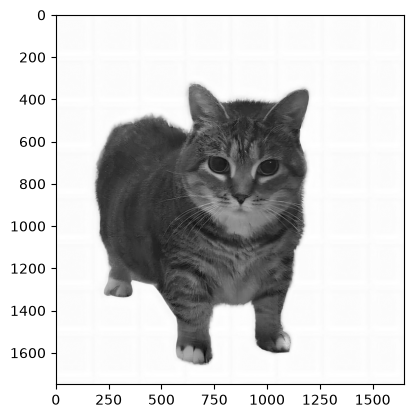

In [361]:
cat_img_gray = img_to_gray(cat_img)
cat_img_gray = cat_img_gray
plt.imshow(cat_img_gray, cmap="gray")

In [110]:
cat_img_gray.shape

(500, 300)

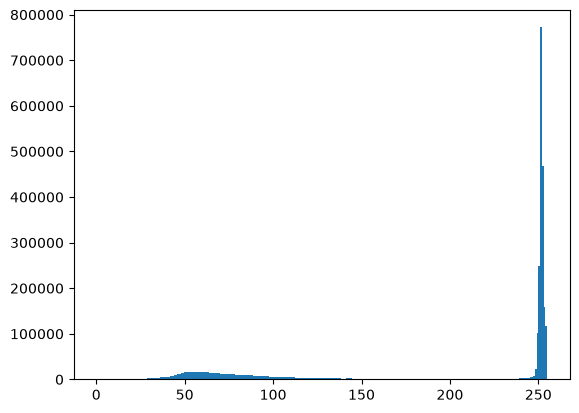

In [310]:
values, bins, patches = plt.hist(cat_img_gray.ravel(), bins=256, range=(0, 255))
plt.show()

bins = bins[:256].astype(np.int16)

In [243]:
# H(i) = values[i]
def otsu(histogram: np.ndarray, bins):
    total = histogram.sum()
    p = histogram / total
    q1 = q2 = m1 = m2 = s1 = s2 = t_opt = s_w = 0
    s_w_min = -1
    for t in bins:
        q1 = p[:t+1].sum()
        q2 = p[t+1:].sum()
        if q1 == 0 or q2 == 0: continue
        m1 = (bins[:t+1] * p[:t+1] / q1).sum()
        m2 = (bins[t+1:] * p[t+1:] / q2).sum()
        s1 = ((bins[:t+1] - m1) ** 2 * p[:t+1] / q1).sum()
        s2 = ((bins[t+1:] - m2) ** 2 * p[t+1:] / q2).sum()
        s_w = q1 * s1 + q2 * s2
        if s_w <= s_w_min or s_w_min == -1:
            s_w_min = s_w
            t_opt = t
    return t_opt

In [306]:
def binarization(img, threshold):
    return (img <= threshold).astype(np.uint8)

Threshold: 163
(1750, 1650) uint8


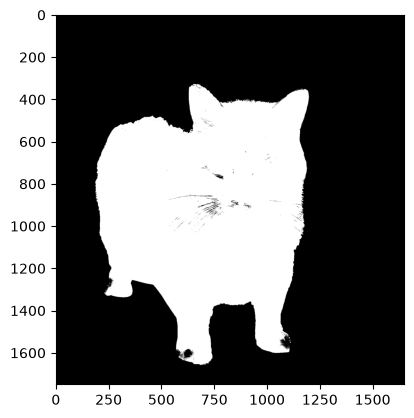

In [358]:
threshold = otsu(values, bins)
print(f"Threshold: {threshold}")
mask = binarization(cat_img_gray, threshold)
print(mask.shape, mask.dtype)
plt.imshow(mask, cmap="gray")

(1750, 1650, 3)
(2336, 3504, 3)


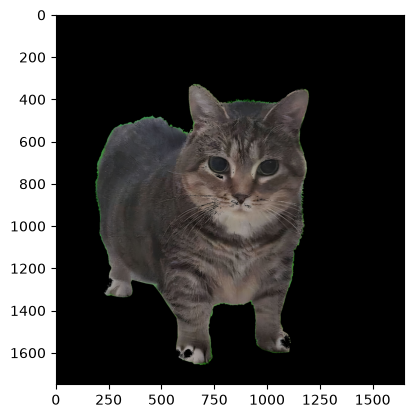

In [362]:
s = cat_img * mask[:, :, None]
plt.imshow(s)
print(s.shape)
print(bg_img.shape)

In [348]:
def compose(img1, img2, img2_mask, x, y):
    img_res = img1.copy()
    img_res[x:img2.shape[0]+x, y:img2.shape[1]+y, :] = np.where(img2_mask[:, :, None] != 0, img2, img_res[x:img2.shape[0]+x, y:img2.shape[1]+y, :])
    return img_res

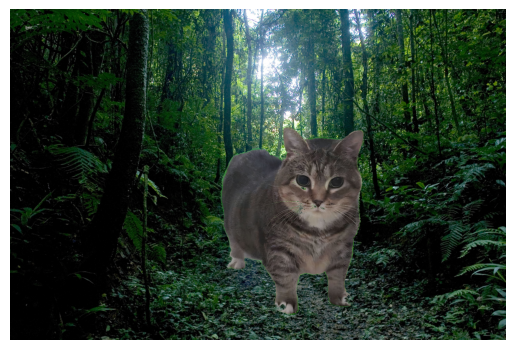

In [360]:
img = compose(bg_img, cat_img, mask, 500, 1300)
plt.axis("off")
plt.imshow(img)